# 数据集加载及预处理

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
# 这个Dataset类用于将加利福尼亚房价特征和标签包装成PyTorch能读的数据格式
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        # X 是输入的特征，形状是 [样本数, 特征数]，这里转为float型张量
        self.X = torch.FloatTensor(X)
        # y 是目标房价，是一维的数组（每个样本一个目标值），同样转为float型张量
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        # 返回数据集中样本的数量
        return len(self.X)
    
    def __getitem__(self, idx):
        # 该方法用于通过索引idx获取样本
        # self.X[idx] 取得第idx个样本的特征，是一维张量（特征数，）
        # self.y[idx] 取得第idx个样本的标签，是标量
        # 因为用于回归问题，通常标签形状最好为[1]而不是标量，所以对y使用unsqueeze(0)增加一个维度
        # 这样返回的特征是[tensor(特征数, )]，标签是[tensor(1, )]
        return self.X[idx], self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [16]:
for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 1])


In [17]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [18]:
class WideDeep(nn.Module):
    """
    Wide & Deep 模型。
    将原始输入特征 x（wide部分）与一个小型全连接神经网络（deep部分）提取出来的特征拼接，
    然后送入输出层做回归预测。
    """
    def __init__(self, input_dim=8):
        """
        参数:
            input_dim: 输入特征的个数（加州房价数据集为8个特征）
        """
        super().__init__()
        # deep部分：由两层全连接层组成，每层都有relu激活函数
        # nn.Sequential 方便把多层顺序组装到一起
        self.deep = nn.Sequential(
            nn.Linear(input_dim, 30),  # 第一层：输入dim->30个神经元
            nn.ReLU(),                 # 激活函数
            nn.Linear(30, 30),         # 第二层：30个神经元->30个神经元
            nn.ReLU()
        )
        # 输出层输入为 wide（原始x）和 deep 部分拼接后的特征，维度=input_dim+30
        # 输出1个回归值
        self.output_layer = nn.Linear(30 + input_dim, 1)
        
        # 初始化网络权重参数
        self.init_weights()
        
    def init_weights(self):
        """
        用 Xavier 均匀分布初始化所有全连接层的权重W，偏置b初始化为0
        这样有助于网络收敛和训练稳定。
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):              # 查找模型的所有 nn.Linear 层
                nn.init.xavier_uniform_(m.weight)     # 使用 xavier 均匀分布初始化权重
                nn.init.zeros_(m.bias)                # 偏置初始化为0
        
    def forward(self, x):
        """
        前向计算
        输入:
            x: shape为 [batch_size, input_dim]
        返回:
            logits: shape为 [batch_size, 1]
        """
        # deep部分前向传播，得到 [batch_size, 30] 特征
        deep_output = self.deep(x)
        # 拼接wide部分（输入x）和deep部分，得到 [batch_size, input_dim + 30]

        # 将原始输入特征（wide部分，形状为 [batch_size, input_dim]）
        # 和神经网络提取的深层特征（deep部分，形状为 [batch_size, 30]）在特征维（dim=1）拼接
        # 拼接后得到的张量形状为 [batch_size, input_dim + 30]
        # wide部分这里就是直接用原始输入x，不经过额外的线性层处理；
        
        # 这种做法正是"Wide & Deep"模型思想：wide分支保持原有特征（保持线性信息），
        # deep分支提取到的非线性特征。拼接时直接用原始x就可以，不需要先过线性层。
        concat = torch.cat([x, deep_output], dim=1)
        # 输出层，回归输出 [batch_size, 1]
        logits = self.output_layer(concat)
        return logits


In [19]:
# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 前向计算验证 WideDeep 模型
# 创建模型实例并移动到合适设备
model = WideDeep(input_dim=8)
model.to(device)  # 可根据实际设备选择 'cuda' 或 'cpu'

# 随机生成一个与输入维度匹配的批量样本
x_sample = torch.randn(4, 8)  # 假设batch size为4, 特征数为8
output = model(x_sample)

print(f"输入形状: {x_sample.shape}")
print(f"模型输出形状: {output.shape}")
print(f"模型输出内容:\n{output}")


使用设备: cpu
输入形状: torch.Size([4, 8])
模型输出形状: torch.Size([4, 1])
模型输出内容:
tensor([[0.3643],
        [0.5451],
        [0.6876],
        [0.3654]], grad_fn=<AddmmBackward0>)


In [20]:
# 导入自定义训练模块，包含训练器、早停机制和模型检查点功能
from wangdao_train import Trainer, EarlyStopping, ModelCheckpoint

# ========================== 损失函数与优化器初始化 ==========================

# 定义损失函数（此处为均方误差损失，适合回归任务）
criterion = nn.MSELoss()  # nn.MSELoss() 会计算输出与目标之间的均方差

# 定义优化器（Adam优化器能自适应调整学习率，常用于深度学习任务）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # lr为学习率

# ========================== 早停机制配置 ==========================

# 初始化EarlyStopping，对验证集性能长期不提升时提前终止训练
early_stopping = EarlyStopping(
    patience=10,      # 当超过10个评估周期(val_loss)无提升则早停
    min_delta=0.001,  # 只有当val_loss较历史最优减少超过0.001才认为有提升
    mode='min'        # 'min'表示以val_loss越小越好为目标监控
)

# ========================== 模型检查点配置 ==========================

# 初始化模型检查点对象，每次val_loss取得历史新低时保存一次模型参数
model_checkpoint = ModelCheckpoint(
    filepath='./checkpoints/regression_model_epoch_{epoch}.ckpt',  # 保存路径，{epoch}会被当前轮数替换
    monitor='val_loss',         # 监控指标为验证集损失
    save_best_only=True,        # 只保存val_loss最优时的模型
    mode='min',                 # val_loss越小越好
    min_delta=0.001             # 只有val_loss较上次最好记录下降超过0.001时才保存
)

# ========================== 训练器实例化 ==========================

# 创建Trainer对象，负责整个训练、验证流程，集成早停和模型保存功能
trainer = Trainer(
    model=model,                    # 要训练的模型
    train_loader=train_loader,      # 训练集的DataLoader
    val_loader=val_loader,          # 验证集的DataLoader
    criterion=criterion,            # 损失函数
    optimizer=optimizer,            # 优化器
    device=device,                  # 训练设备(CPU或GPU)
    eval_step=50,                   # 每50个batch在验证集上评估一次表现
    early_stopping=early_stopping,  # 早停监控对象
    model_checkpoint=model_checkpoint  # 模型检查点保存对象
)

# ========================== 开始训练 ==========================

print("开始训练...")  # 打印提示信息

# 调用Trainer进行回归任务训练，指定总轮数为100
trainer.train_regression(num_epochs=100)


开始训练...
[Step 50] Val Loss: 1.7406
[Step 100] Val Loss: 0.9692
[Step 150] Val Loss: 0.8123
[Step 200] Val Loss: 0.7283
Epoch [1/100]  Train Loss: 1.8828
[Step 250] Val Loss: 0.6693
[Step 300] Val Loss: 0.6301
[Step 350] Val Loss: 0.5996
[Step 400] Val Loss: 0.5681
[Step 450] Val Loss: 0.5446
Epoch [2/100]  Train Loss: 0.7472
[Step 500] Val Loss: 0.5164
[Step 550] Val Loss: 0.5004
[Step 600] Val Loss: 0.4851
[Step 650] Val Loss: 0.4748
Epoch [3/100]  Train Loss: 0.5406
[Step 700] Val Loss: 0.4672
[Step 750] Val Loss: 0.4673
[Step 800] Val Loss: 0.4588
[Step 850] Val Loss: 0.4450
[Step 900] Val Loss: 0.4389
Epoch [4/100]  Train Loss: 0.4458
[Step 950] Val Loss: 0.4334
[Step 1000] Val Loss: 0.4358
[Step 1050] Val Loss: 0.4249
[Step 1100] Val Loss: 0.4265
Epoch [5/100]  Train Loss: 0.4124
[Step 1150] Val Loss: 0.4201
[Step 1200] Val Loss: 0.4195
[Step 1250] Val Loss: 0.4131
[Step 1300] Val Loss: 0.4127
[Step 1350] Val Loss: 0.4095
Epoch [6/100]  Train Loss: 0.3965
[Step 1400] Val Loss: 0.4

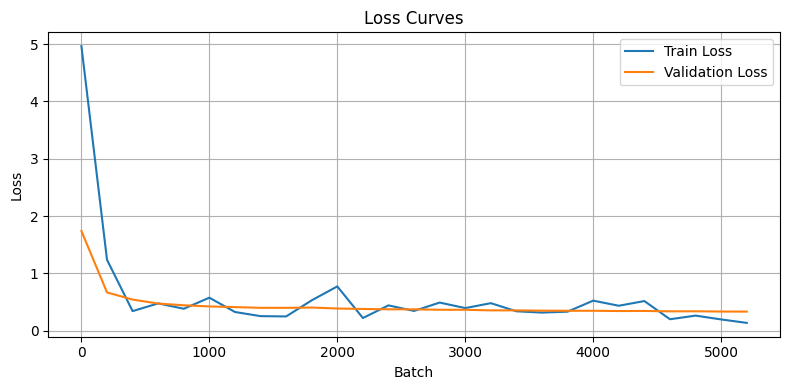

In [21]:
trainer.plot_curves(200)